# Dataset Preparation & Cleaning
## Module 3 - Computer Vision Learning

This notebook handles:
1. Dataset exploration and information
2. Data cleaning (corrupted files, duplicates)
3. Train/Val/Test split

**Note**: Run this locally before using the Colab training notebook.

In [4]:
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import hashlib
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Define paths - robust handling for different execution contexts
current_dir = Path.cwd()

# Strategy: Find the module3 directory by checking multiple possible locations
BASE_DIR = None

# Check 1: Are we already in or near the module3 directory?
if current_dir.name == 'module3' or (current_dir / 'dataset').exists():
    BASE_DIR = current_dir / 'dataset'
# Check 2: Is Chapter2/module3 relative to current directory?
elif (current_dir / 'Chapter2' / 'module3' / 'dataset').exists():
    BASE_DIR = current_dir / 'Chapter2' / 'module3' / 'dataset'
# Check 3: Search parent directories for Chapter2/module3
else:
    search_dir = current_dir
    for _ in range(10):  # Search up to 10 levels
        potential_path = search_dir / 'Chapter2' / 'module3' / 'dataset'
        if potential_path.exists():
            BASE_DIR = potential_path
            break
        search_dir = search_dir.parent
        if search_dir == search_dir.parent:  # Reached filesystem root
            break

# Fallback if not found
if BASE_DIR is None:
    BASE_DIR = current_dir / 'Chapter2' / 'module3' / 'dataset'

RAW_DIR = BASE_DIR / 'raw'
PROCESSED_DIR = BASE_DIR / 'processed'
SPLITS_DIR = BASE_DIR / 'splits'

# Create processed directory if it doesn't exist
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Current working directory: {current_dir}")
print(f"Dataset base path: {BASE_DIR}")
print(f"Raw dataset path: {RAW_DIR}")
print(f"Raw dataset exists: {RAW_DIR.exists()}")

if not RAW_DIR.exists():
    print(f"\n❌ ERROR: Raw dataset not found at:")
    print(f"   {RAW_DIR}")
    print(f"\n✅ SOLUTION: Make sure to run this notebook from the project root directory:")
    print(f"\n   Option 1: Using terminal:")
    print(f"   $ cd '/home/argha-ds/datascience/computer vision/learning-assignments'")
    print(f"   $ source .venv/bin/activate")
    print(f"   $ jupyter notebook Chapter2/module3/01_dataset_preparation.ipynb")
    print(f"\n   Option 2: Using Jupyter directly:")
    print(f"   $ jupyter notebook --notebook-dir='/home/argha-ds/datascience/computer vision/learning-assignments' Chapter2/module3/01_dataset_preparation.ipynb")
    raise FileNotFoundError(f"Dataset not found at {RAW_DIR}")

Current working directory: /home/argha-ds/datascience/computer vision/learning-assignments/Chapter2/module3
Dataset base path: /home/argha-ds/datascience/computer vision/learning-assignments/Chapter2/module3/dataset
Raw dataset path: /home/argha-ds/datascience/computer vision/learning-assignments/Chapter2/module3/dataset/raw
Raw dataset exists: True


## Step 1: Dataset Exploration & Information


DATASET OVERVIEW
Number of classes: 3

Class distribution:
  hibiscus       :  57 images ( 34.3%)
  rose           :  47 images ( 28.3%)
  sunflower      :  62 images ( 37.3%)

Total images: 166


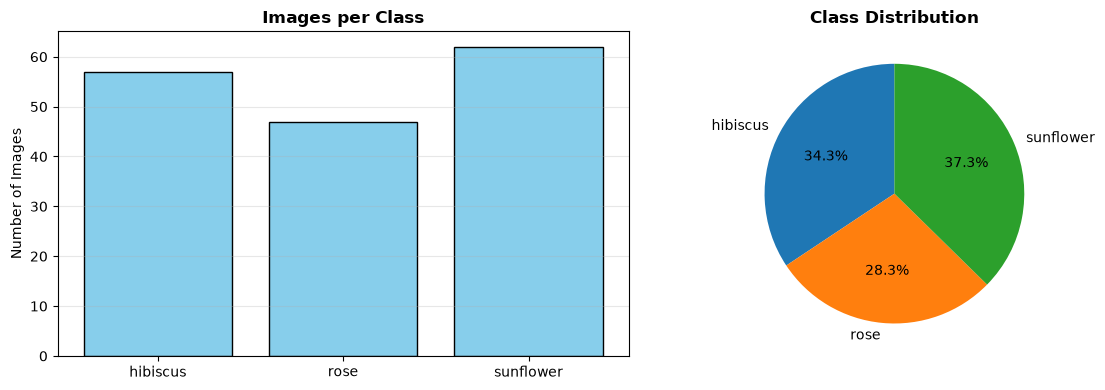


Visualization saved to: /home/argha-ds/datascience/computer vision/learning-assignments/Chapter2/module3/dataset/processed/class_distribution_before_cleaning.png


In [5]:
def explore_dataset(raw_dir):
    """
    Explore raw dataset structure and gather statistics.
    """
    classes = {}
    
    for class_dir in sorted(raw_dir.iterdir()):
        if class_dir.is_dir():
            class_name = class_dir.name
            images = list(class_dir.glob('*.*'))
            classes[class_name] = images
    
    return classes

classes = explore_dataset(RAW_DIR)

print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Number of classes: {len(classes)}")
print(f"\nClass distribution:")

total_images = 0
class_stats = []

for class_name, images in sorted(classes.items()):
    count = len(images)
    total_images += count
    percentage = (count / sum(len(v) for v in classes.values())) * 100
    print(f"  {class_name:15s}: {count:3d} images ({percentage:5.1f}%)")
    class_stats.append({'Class': class_name, 'Images': count, 'Percentage': percentage})

print(f"\nTotal images: {total_images}")
print("="*60)

# Visualize class distribution
df_stats = pd.DataFrame(class_stats)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(df_stats['Class'], df_stats['Images'], color='skyblue', edgecolor='black')
axes[0].set_title('Images per Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(df_stats['Images'], labels=df_stats['Class'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'class_distribution_before_cleaning.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {PROCESSED_DIR / 'class_distribution_before_cleaning.png'}")

## Step 2: Data Cleaning

In [6]:
def check_image_validity(image_path):
    """
    Check if an image file is valid and not corrupted.
    Returns: (is_valid, error_message)
    """
    try:
        img = Image.open(image_path)
        img.verify()
        return True, None
    except Exception as e:
        return False, str(e)

def get_image_hash(image_path):
    """
    Calculate SHA256 hash of image file for duplicate detection.
    """
    try:
        with open(image_path, 'rb') as f:
            return hashlib.sha256(f.read()).hexdigest()
    except Exception as e:
        return None

# Step 2a: Find corrupted files
print("\n" + "="*60)
print("STEP 2A: DETECTING CORRUPTED FILES")
print("="*60)

corrupted_files = []

for class_name, images in classes.items():
    print(f"\nChecking {class_name}...")
    for img_path in tqdm(images, desc=f"Validating {class_name}"):
        is_valid, error = check_image_validity(img_path)
        if not is_valid:
            corrupted_files.append((img_path, error))
            print(f"  ✗ Corrupted: {img_path.name} - {error}")

if corrupted_files:
    print(f"\n⚠️  Found {len(corrupted_files)} corrupted files")
    for img_path, error in corrupted_files:
        print(f"  - {img_path.relative_to(RAW_DIR)}: {error}")
else:
    print(f"\n✓ All images are valid!")


STEP 2A: DETECTING CORRUPTED FILES

Checking hibiscus...


Validating hibiscus: 100%|██████████| 57/57 [00:00<00:00, 811.86it/s]



Checking rose...


Validating rose: 100%|██████████| 47/47 [00:00<00:00, 1027.95it/s]



Checking sunflower...


Validating sunflower: 100%|██████████| 62/62 [00:00<00:00, 899.59it/s]


✓ All images are valid!


In [7]:
# Step 2b: Find duplicate/identical images
print("\n" + "="*60)
print("STEP 2B: DETECTING DUPLICATE IMAGES")
print("="*60)

hash_to_files = defaultdict(list)

print("\nCalculating image hashes...")
for class_name, images in classes.items():
    for img_path in tqdm(images, desc=f"Hashing {class_name}"):
        # Skip already detected corrupted files
        if any(img_path == cf[0] for cf in corrupted_files):
            continue
        img_hash = get_image_hash(img_path)
        if img_hash:
            hash_to_files[img_hash].append(img_path)

# Find duplicates
duplicates = {h: paths for h, paths in hash_to_files.items() if len(paths) > 1}

if duplicates:
    print(f"\n⚠️  Found {len(duplicates)} sets of duplicate images:")
    duplicate_count = sum(len(paths) - 1 for paths in duplicates.values())
    print(f"   Total duplicate images to remove: {duplicate_count}")
    for i, (hash_val, paths) in enumerate(duplicates.items(), 1):
        print(f"\n  Duplicate set {i}:")
        for path in paths:
            print(f"    - {path.relative_to(RAW_DIR)}")
else:
    print(f"\n✓ No duplicate images found!")
    duplicates = {}
    duplicate_count = 0


STEP 2B: DETECTING DUPLICATE IMAGES

Calculating image hashes...


Hashing sunflower: 100%|██████████| 62/62 [00:00<00:00, 757.40it/s]


⚠️  Found 9 sets of duplicate images:
   Total duplicate images to remove: 9

  Duplicate set 1:
    - hibiscus/24.jpeg
    - hibiscus/29.jpeg

  Duplicate set 2:
    - hibiscus/12.jpeg
    - hibiscus/18.jpeg

  Duplicate set 3:
    - rose/19.jpeg
    - rose/18.jpeg

  Duplicate set 4:
    - rose/6.jpeg
    - rose/10.jpeg

  Duplicate set 5:
    - rose/36.jpeg
    - rose/34.jpeg

  Duplicate set 6:
    - sunflower/45.jpeg
    - sunflower/42.jpeg

  Duplicate set 7:
    - sunflower/43.jpeg
    - sunflower/40.jpeg

  Duplicate set 8:
    - sunflower/41.jpeg
    - sunflower/44.jpeg

  Duplicate set 9:
    - sunflower/7.jpeg
    - sunflower/5.jpeg


In [8]:
# Step 2c: Remove corrupted and duplicate files
print("\n" + "="*60)
print("STEP 2C: REMOVING CORRUPTED AND DUPLICATE FILES")
print("="*60)

removed_count = 0

# Remove corrupted files
if corrupted_files:
    print(f"\nRemoving {len(corrupted_files)} corrupted files...")
    for img_path, _ in corrupted_files:
        try:
            img_path.unlink()
            print(f"  ✓ Removed: {img_path.name}")
            removed_count += 1
        except Exception as e:
            print(f"  ✗ Failed to remove {img_path.name}: {e}")

# Remove one copy from each duplicate set (keep the first)
if duplicates:
    print(f"\nRemoving duplicate copies (keeping first of each set)...")
    for hash_val, paths in duplicates.items():
        # Keep first, remove rest
        for img_path in paths[1:]:
            try:
                img_path.unlink()
                print(f"  ✓ Removed: {img_path.relative_to(RAW_DIR)}")
                removed_count += 1
            except Exception as e:
                print(f"  ✗ Failed to remove {img_path.name}: {e}")

print(f"\n✓ Removed {removed_count} files in total")

# Re-explore dataset after cleaning
classes_cleaned = explore_dataset(RAW_DIR)


STEP 2C: REMOVING CORRUPTED AND DUPLICATE FILES

Removing duplicate copies (keeping first of each set)...
  ✓ Removed: hibiscus/29.jpeg
  ✓ Removed: hibiscus/18.jpeg
  ✓ Removed: rose/18.jpeg
  ✓ Removed: rose/10.jpeg
  ✓ Removed: rose/34.jpeg
  ✓ Removed: sunflower/42.jpeg
  ✓ Removed: sunflower/40.jpeg
  ✓ Removed: sunflower/44.jpeg
  ✓ Removed: sunflower/5.jpeg

✓ Removed 9 files in total


## Step 3: Train/Val/Test Split

In [9]:
# Step 3a: Create directory structure
print("\n" + "="*60)
print("STEP 3A: CREATING DATASET STRUCTURE")
print("="*60)

# Remove old splits directory if exists
if SPLITS_DIR.exists():
    shutil.rmtree(SPLITS_DIR)
    print(f"Removed existing splits directory")

# Create train/val/test structure
for split in ['train', 'val', 'test']:
    for class_name in classes_cleaned.keys():
        split_class_dir = SPLITS_DIR / split / class_name
        split_class_dir.mkdir(parents=True, exist_ok=True)
        print(f"Created: {split_class_dir.relative_to(BASE_DIR)}")

print(f"\n✓ Directory structure created at: {SPLITS_DIR}")


STEP 3A: CREATING DATASET STRUCTURE
Created: splits/train/hibiscus
Created: splits/train/rose
Created: splits/train/sunflower
Created: splits/val/hibiscus
Created: splits/val/rose
Created: splits/val/sunflower
Created: splits/test/hibiscus
Created: splits/test/rose
Created: splits/test/sunflower

✓ Directory structure created at: /home/argha-ds/datascience/computer vision/learning-assignments/Chapter2/module3/dataset/splits


In [10]:
# Step 3b: Split and copy images
print("\n" + "="*60)
print("STEP 3B: SPLITTING AND COPYING IMAGES")
print("="*60)

# Split ratios: 70% train, 15% val, 15% test
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

split_stats = []

print(f"\nSplit ratios: Train={train_ratio*100:.0f}%, Val={val_ratio*100:.0f}%, Test={test_ratio*100:.0f}%\n")

total_train = total_val = total_test = 0

for class_name in sorted(classes_cleaned.keys()):
    images = sorted(classes_cleaned[class_name])  # Sort for reproducibility
    n_images = len(images)
    
    # Shuffle indices while maintaining seed
    indices = np.arange(n_images)
    np.random.shuffle(indices)
    
    # Calculate split indices
    train_idx = int(n_images * train_ratio)
    val_idx = int(n_images * (train_ratio + val_ratio))
    
    train_images = [images[i] for i in indices[:train_idx]]
    val_images = [images[i] for i in indices[train_idx:val_idx]]
    test_images = [images[i] for i in indices[val_idx:]]
    
    print(f"\n{class_name}:")
    print(f"  Total: {n_images} images")
    print(f"  Train: {len(train_images)} images")
    print(f"  Val:   {len(val_images)} images")
    print(f"  Test:  {len(test_images)} images")
    
    # Copy files
    for img_path in tqdm(train_images, desc=f"Copying {class_name} to train"):
        dest = SPLITS_DIR / 'train' / class_name / img_path.name
        shutil.copy2(img_path, dest)
    
    for img_path in tqdm(val_images, desc=f"Copying {class_name} to val"):
        dest = SPLITS_DIR / 'val' / class_name / img_path.name
        shutil.copy2(img_path, dest)
    
    for img_path in tqdm(test_images, desc=f"Copying {class_name} to test"):
        dest = SPLITS_DIR / 'test' / class_name / img_path.name
        shutil.copy2(img_path, dest)
    
    split_stats.append({
        'Class': class_name,
        'Train': len(train_images),
        'Val': len(val_images),
        'Test': len(test_images),
        'Total': n_images
    })
    
    total_train += len(train_images)
    total_val += len(val_images)
    total_test += len(test_images)

print("\n" + "="*60)
print("SPLIT SUMMARY")
print("="*60)

df_splits = pd.DataFrame(split_stats)
print("\n", df_splits.to_string(index=False))
print(f"\nTotals:")
print(f"  Train: {total_train} images")
print(f"  Val:   {total_val} images")
print(f"  Test:  {total_test} images")
print(f"  Total: {total_train + total_val + total_test} images")


STEP 3B: SPLITTING AND COPYING IMAGES

Split ratios: Train=70%, Val=15%, Test=15%


hibiscus:
  Total: 55 images
  Train: 38 images
  Val:   8 images
  Test:  9 images


Copying hibiscus to test: 100%|██████████| 9/9 [00:00<00:00, 718.79it/s]



rose:
  Total: 44 images
  Train: 30 images
  Val:   7 images
  Test:  7 images


Copying rose to test: 100%|██████████| 7/7 [00:00<00:00, 330.75it/s]



sunflower:
  Total: 58 images
  Train: 40 images
  Val:   9 images
  Test:  9 images


Copying sunflower to test: 100%|██████████| 9/9 [00:00<00:00, 668.41it/s]



SPLIT SUMMARY

     Class  Train  Val  Test  Total
 hibiscus     38    8     9     55
     rose     30    7     7     44
sunflower     40    9     9     58

Totals:
  Train: 108 images
  Val:   24 images
  Test:  25 images
  Total: 157 images


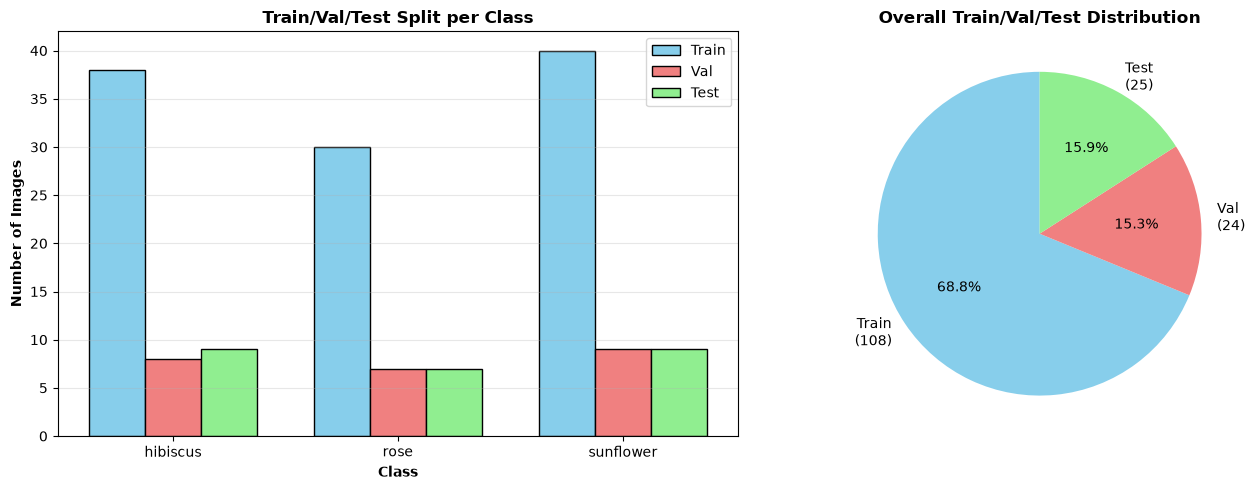


✓ Split visualization saved to: /home/argha-ds/datascience/computer vision/learning-assignments/Chapter2/module3/dataset/processed/train_val_test_split.png


In [11]:
# Step 3c: Visualize final split distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
x = np.arange(len(df_splits))
width = 0.25

axes[0].bar(x - width, df_splits['Train'], width, label='Train', color='skyblue', edgecolor='black')
axes[0].bar(x, df_splits['Val'], width, label='Val', color='lightcoral', edgecolor='black')
axes[0].bar(x + width, df_splits['Test'], width, label='Test', color='lightgreen', edgecolor='black')

axes[0].set_xlabel('Class', fontweight='bold')
axes[0].set_ylabel('Number of Images', fontweight='bold')
axes[0].set_title('Train/Val/Test Split per Class', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_splits['Class'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Pie chart for overall split
split_totals = [total_train, total_val, total_test]
split_labels = [f'Train\n({total_train})', f'Val\n({total_val})', f'Test\n({total_test})']
colors_split = ['skyblue', 'lightcoral', 'lightgreen']

axes[1].pie(split_totals, labels=split_labels, autopct='%1.1f%%', colors=colors_split, startangle=90)
axes[1].set_title('Overall Train/Val/Test Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'train_val_test_split.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✓ Split visualization saved to: {PROCESSED_DIR / 'train_val_test_split.png'}")

## Summary & Cleanup Report

In [12]:
print("\n" + "="*60)
print("DATASET PREPARATION COMPLETE")
print("="*60)

print(f"\n📊 Summary:")
print(f"  • Original images: {sum(len(v) for v in classes.values())}")
print(f"  • Corrupted files removed: {len(corrupted_files)}")
print(f"  • Duplicate files removed: {duplicate_count}")
print(f"  • Final clean images: {total_train + total_val + total_test}")

print(f"\n📁 Dataset location:")
print(f"  {SPLITS_DIR}")

print(f"\n✓ Ready for model training on Google Colab!")
print(f"  Use notebook: 02_model_training_colab.ipynb")


DATASET PREPARATION COMPLETE

📊 Summary:
  • Original images: 166
  • Corrupted files removed: 0
  • Duplicate files removed: 9
  • Final clean images: 157

📁 Dataset location:
  /home/argha-ds/datascience/computer vision/learning-assignments/Chapter2/module3/dataset/splits

✓ Ready for model training on Google Colab!
  Use notebook: 02_model_training_colab.ipynb
